In [1]:
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.io as sio
import pandas as pd


In [8]:
home_dir = "/Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/"
manuscript_dir = home_dir + "Work/Manuscripts/2019_06 SO CMIP Comparison/"

plot_ver = '_v21' # this should be saved in the variable files, can check for it later

In [9]:
df = pd.read_csv(manuscript_dir + 'spreadsheets/Table_taylor_results' + plot_ver + '.csv',  index_col=[0])
df

,fgco2_correlation,fgco2_ratio,fgco2_norm_error,spco2_correlation,spco2_ratio,spco2_norm_error,dissic_correlation,dissic_ratio,dissic_norm_error,tos_correlation,...,sos_norm_error,talk_correlation,talk_ratio,talk_norm_error,mld_correlation,mld_ratio,mld_norm_error,intpp_correlation,intpp_ratio,intpp_norm_error
Model_Name,,,,,,,,,,,,,,,,,,,,,
CESM1_BGC,0.940047,0.993045,0.345139,0.963100,0.650144,0.412770,0.968018,1.084228,0.276488,0.999268,...,0.933948,0.981008,0.694166,0.346268,0.988449,0.686764,0.337613,0.905237,2.051872,1.222832
CMCC_CESM,-0.465767,1.762364,2.397421,-0.481389,1.850689,2.491355,0.869248,0.916180,0.496599,0.998601,...,1.536544,0.937341,1.156776,0.411756,0.972380,0.515243,0.513275,0.551346,1.592875,1.334466
CNRM_CM5,-0.835888,0.814696,1.739459,NaN,NaN,NaN,0.827018,0.688405,0.579011,0.994241,...,0.316392,0.855784,0.357668,0.718160,0.996891,0.574626,0.429553,0.699943,1.109819,0.823455
CanESM2,-0.765643,4.689312,5.492752,-0.832143,0.871027,1.791180,0.798582,0.818358,0.602211,0.994447,...,0.341778,0.957677,0.433086,0.598373,0.997448,0.643230,0.361341,0.902611,0.694548,0.478104
GFDL_ESM2G,-0.808774,0.512124,1.445910,-0.827057,0.705590,1.632478,0.900151,0.816169,0.443600,0.997920,...,0.171906,0.893550,0.234662,0.797309,0.981305,0.794599,0.268143,0.917784,2.385854,1.520823
GFDL_ESM2M,-0.558430,0.617588,1.439157,-0.620412,0.772726,1.598726,0.916496,1.022787,0.413923,0.996777,...,0.394806,0.697660,0.225440,0.858058,0.987300,0.676156,0.349355,0.882851,2.448522,1.634595
GISS_E2_H_CC,0.652647,1.151561,0.907175,0.668314,1.550610,1.154038,0.967466,1.992375,1.055675,0.987800,...,2.539017,NaN,NaN,NaN,0.948989,0.960771,0.315529,0.902398,1.078822,0.465622
GISS_E2_R_CC,0.325195,1.142858,1.250129,0.454522,1.095436,1.097352,0.887079,1.317239,0.630975,0.995076,...,0.440813,NaN,NaN,NaN,0.961144,1.590497,0.687232,0.918133,1.450624,0.663761
HadGEM2_CC,0.771617,1.163010,0.746857,0.807837,1.917546,1.256524,0.983545,1.266286,0.335531,0.991247,...,0.585468,0.679243,0.603945,0.737766,0.988004,0.789736,0.251312,0.929602,4.351434,3.441624


### Table 2 - model correlations

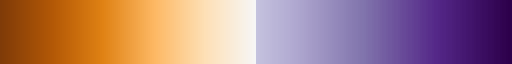

In [ ]:
# set colors for table 2
colors_bad= plt.cm.PuOr(np.linspace(0, 0.5, 256))
colors_good = plt.cm.PuOr(np.linspace(0.65, 1, 256))
all_colors = np.vstack((colors_bad, colors_good))
corr_map = mpl.colors.LinearSegmentedColormap.from_list(
    'corr_map', all_colors)
corr_map

In [13]:
column_names = df.keys()

df_max_min = np.zeros((2,len(column_names)))
for cn in range(0, len(column_names)):
    if 'ratio' in column_names[cn]:
        df_max_min[0,cn] = max(abs(df[column_names[cn]].values-1))
        df_max_min[1,cn] = min(abs(df[column_names[cn]].values-1))
    else:
        df_max_min[0,cn] = max(df[column_names[cn]].values)
        df_max_min[1,cn] = min(df[column_names[cn]].values)
df_max_min

# Don't need to recreate every part of the table, just the main numbers, putting the proper cell colors in pace. 
cmap = corr_map
cmap_flipped = mpl.colormaps["PuOr_r"]


# norm_corr = mpl.colors.Normalize(vmin=-0.6, vmax=1.6)  # want 0 to be the best here. 1x below 0, 3x above. 
# norm_ratio = mpl.colors.Normalize(vmin=-3, vmax=9)
# norm_error = mpl.colors.Normalize(vmin=-3.5, vmax=10.5)


column_names = df.keys()
num_models = df.shape[0]
cmip6_first=0
state_estimate_first = 0
for m in range(0, num_models):
    mod_name = df.index[m]
    mod_values = df.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
        if cmip6_first==0:
            cmip6_first=1
            print("\multicolumn{1}{l}{\\textbf{CMIP6}} \\\\ \midrule")
    if "SOSE" in mod_name_updated:
        if state_estimate_first==0:
            state_estimate_first=1
            print("\multicolumn{1}{l}{\\textbf{State Estimates}} \\\\ \midrule")

    no_data = 0
    print('\\textbf{' + mod_name_updated + '} ', end='')
    for idx, val in enumerate(mod_values):
        print('& ', end='')
        if np.isnan(val):
            print( '-' , end='')
        else:

            if  'correlation' in column_names[idx]:
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                if ('fgco2' in column_names[idx]) | ('spco2' in column_names[idx]):
                    norm_corr = mpl.colors.TwoSlopeNorm(vmin=df_max_min[1,idx] - range_val*.3, vcenter=0.65, vmax=df_max_min[0,idx]+range_val*.2)
                else:
                    norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)

                rgba_color = cmap(norm_corr(val),bytes=True) 
            elif 'ratio' in column_names[idx]:
                # rgba_color = [0,0,0]

                # # for ratio, we want better to be closer to 1. 
                val_color = abs(val - 1)
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)
                rgba_color = cmap_flipped(norm_corr(val_color),bytes=True) 
            elif 'error' in column_names[idx]:
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)
                rgba_color = cmap_flipped(norm_corr(val),bytes=True) 

                # rgba_color = cmap_flipped(norm_error(val),bytes=True) # error is flipped, so closer to 0 is better
            else:
                rgba_color = [0,0,0]
                
            r = rgba_color[0]/255
            g = rgba_color[1]/255
            b = rgba_color[2]/255
            print('\cellcolor[rgb]{' + str(r.round(3)) + ',' + str(g.round(3)) + ','  + str(b.round(3)) + '}' + str(val.round(1)) + ' ', end='')
    print('\\\\', end='')

    print('')



\textbf{CESM1-BGC} & \cellcolor[rgb]{0.494,0.439,0.667}0.9 & \cellcolor[rgb]{0.478,0.416,0.655}1.0 & \cellcolor[rgb]{0.478,0.416,0.655}0.3 & \cellcolor[rgb]{0.486,0.427,0.663}1.0 & \cellcolor[rgb]{0.616,0.576,0.761}0.7 & \cellcolor[rgb]{0.478,0.416,0.655}0.4 & \cellcolor[rgb]{0.439,0.345,0.624}1.0 & \cellcolor[rgb]{0.553,0.51,0.714}1.1 & \cellcolor[rgb]{0.537,0.49,0.702}0.3 & \cellcolor[rgb]{0.38,0.239,0.573}1.0 & \cellcolor[rgb]{0.78,0.773,0.878}1.4 & \cellcolor[rgb]{0.765,0.753,0.867}0.4 & \cellcolor[rgb]{0.475,0.404,0.651}1.0 & \cellcolor[rgb]{0.863,0.871,0.925}1.9 & \cellcolor[rgb]{0.839,0.847,0.918}0.9 & \cellcolor[rgb]{0.38,0.239,0.573}1.0 & \cellcolor[rgb]{0.855,0.863,0.922}0.7 & \cellcolor[rgb]{0.616,0.576,0.761}0.3 & \cellcolor[rgb]{0.475,0.404,0.651}1.0 & \cellcolor[rgb]{0.878,0.882,0.933}0.7 & \cellcolor[rgb]{0.839,0.847,0.918}0.3 & \cellcolor[rgb]{0.431,0.333,0.616}0.9 & \cellcolor[rgb]{0.729,0.71,0.843}2.1 & \cellcolor[rgb]{0.686,0.655,0.812}1.2 \\
\textbf{CMCC-CESM} & \ce

In [ ]:
# ('fgco2' in column_names[idx]) | ('spco2' in column_names[idx])

True

In [ ]:
# for idx, val in enumerate(mod_values):
#     print('& ', end='')
#     if np.isnan(val):
#         print( '-' , end='')
#     else:

#         if  'correlation' in column_names[idx]:
#             range_val = df_max_min[0,idx] - df_max_min[1,idx]

#             norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.5)
#             rgba_color = cmap(norm_corr(val),bytes=True) 
#             break    
    

& 

### Table 1 - model variants

In [16]:
df2 = pd.read_csv(manuscript_dir + 'spreadsheets/ensemble_members' + plot_ver + '.csv',  index_col=[0])
df2

,Variant
Model_Name,
CESM1_BGC,r1i1p1
CMCC_CESM,r1i1p1
CNRM_CM5,r1i1p1
CanESM2,r1i1p1
GFDL_ESM2G,r1i1p1
GFDL_ESM2M,r1i1p1
GISS_E2_H_CC,r1i1p1
GISS_E2_R_CC,r1i1p1
HadGEM2_CC,r2i1p1


In [11]:
column_names = df2.keys()
num_models = df2.shape[0]

for m in range(0, 19):
    mod_name = df2.index[m]
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
    print('\\textbf{' + mod_name_updated + '} ', end='')
    print('& ', end='')
    print(mod_values[0], end='')
    print(' &  x & ', end='')

    # try printing CMIP6 in the right 3 columns
    mod_name = df2.index[m+19]
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
    print('\\textbf{' + mod_name_updated + '} ', end='')
    print('& ', end='')
    variant = mod_values[0].replace('_','-')
    print(variant, end='')
    print(' &  x ', end='')

    print('\\\\', end='')
    print('')

for m in range(38, 42):
    print(' &  & &  ', end='')
    mod_name = df2.index[m]
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
    print('\\textbf{' + mod_name_updated + '} ', end='')
    print('& ', end='')
    variant = mod_values[0].replace('_','-')
    print(variant, end='')
    print(' &  x ', end='')
    print('\\\\', end='')
    print('')
    
for m in range(42, num_models):
    mod_name = df2.index[m]
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
    print('\\textbf{' + mod_name_updated + '} ', end='')
    print('& ', end='')
    print(mod_values[0], end='')
    print(' &  x ', end='')
    print('\\\\', end='')
    print('')

\textbf{CESM1-BGC} & r1i1p1 &  x & \textbf{ACCESS-ESM1-5 (6)} & r1i1p1f1-gn &  x \\
\textbf{CMCC-CESM} & r1i1p1 &  x & \textbf{AWI-ESM-1-REcoM (6)} & r1i1p1f1-gr1 &  x \\
\textbf{CNRM-CM5} & r1i1p1 &  x & \textbf{CESM2-WACCM (6)} & r1i1p1f1-gr &  x \\
\textbf{CanESM2} & r1i1p1 &  x & \textbf{CESM2 (6)} & r4i1p1f1-gn &  x \\
\textbf{GFDL-ESM2G} & r1i1p1 &  x & \textbf{CMCC-ESM2 (6)} & r1i1p1f1-gn &  x \\
\textbf{GFDL-ESM2M} & r1i1p1 &  x & \textbf{CNRM-ESM2-1 (6)} & r1i1p1f2-gn &  x \\
\textbf{GISS-E2-H-CC} & r1i1p1 &  x & \textbf{CanESM5-1 (6)} & r1i1p1f1-gn &  x \\
\textbf{GISS-E2-R-CC} & r1i1p1 &  x & \textbf{CanESM5-CanOE (6)} & r1i1p2f1-gn &  x \\
\textbf{HadGEM2-CC} & r2i1p1 &  x & \textbf{CanESM5 (6)} & r1i1p2f1-gn &  x \\
\textbf{HadGEM2-ES} & r2i1p1 &  x & \textbf{EC-Earth3-CC (6)} & r1i1p1f1-gn &  x \\
\textbf{IPSL-CM5A-LR} & r1i1p1 &  x & \textbf{GFDL-CM4 (6)} & r1i1p1f1-gr &  x \\
\textbf{IPSL-CM5A-MR} & r1i1p1 &  x & \textbf{GFDL-ESM4 (6)} & r1i1p1f1-gr &  x \\
\textbf{IPSL

In [ ]:
# if "-6" in mod_name_updated:
#     mod_name_updated = mod_name_updated.replace('-6', ' (6)')
# mod_name_updated

'GFDL-ESM4 (6)'

### Table 3 - pCO2 correlation improvement

In [14]:
df2 = pd.read_csv(manuscript_dir + 'spreadsheets/dataTable_correlations_only_v21_2026_06_16.csv',  index_col=[0])
df2

,orig_pco2_corr,dic_phase_adj_pco2_corr,dic_amp_adj_pco2_corr,dic_phase_amp_adj_pco2_corr,sst_amp_adj_pco2_corr,talk_phase_adj_pco2_corr,talk_amp_adj_pco2_corr,talk_phase_amp_adj_pco2_corr,dic_phase_amp_sst_phase_amp_adj_pco2_corr,dic_sst_ta_adj_pco2_corr,T_B_ratio
model_name,,,,,,,,,,,
CESM1_BGC,0.964227,0.971606,0.976727,0.933231,0.888457,0.951259,0.959260,0.969989,0.956423,0.973555,0.831459
CMCC_CESM,-0.614364,-0.276183,-0.551863,-0.036158,0.964830,-0.690843,-0.649202,-0.722907,0.964519,0.973523,1.732589
CanESM2,-0.797035,0.618597,-0.298679,0.966325,-0.067475,-0.799601,-0.975729,-0.972596,0.901224,0.973758,1.069577
GFDL_ESM2G,-0.918390,-0.006055,-0.420707,0.753556,0.497101,-0.942783,-0.591268,-0.779203,0.912898,0.975111,1.317290
GFDL_ESM2M,-0.921130,0.072433,-0.895085,-0.032089,0.661657,-0.953072,-0.365293,-0.788879,0.914221,0.975272,1.236081
GISS_E2_H_CC,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GISS_E2_R_CC,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HadGEM2_CC,0.924238,0.974771,0.792844,0.902603,0.972157,0.917787,0.866455,0.816670,0.963493,0.974537,0.744778
HadGEM2_ES,0.889580,0.970299,0.817300,0.931815,0.969566,0.880458,0.803953,0.744173,0.961556,0.974401,0.787139


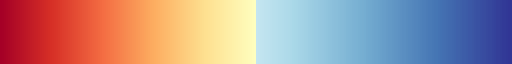

In [15]:
colors_bad= plt.cm.RdYlBu(np.linspace(0, 0.5, 256))
colors_good = plt.cm.RdYlBu(np.linspace(0.65, 1, 256))
all_colors = np.vstack((colors_bad, colors_good))
corr_map = mpl.colors.LinearSegmentedColormap.from_list(
    'corr_map', all_colors)
corr_map

In [16]:
column_names = df2.keys()

# Don't need to recreate every part of the table, just the main numbers, putting the proper cell colors in pace. 
# cmap = mpl.colormaps["RdYlBu"]
cmap = corr_map

# norm_corr = mpl.colors.Normalize(vmin=-1.25, vcenter=0.65, vmax=1.25)
norm_corr = mpl.colors.TwoSlopeNorm(vmin=-1.25, vcenter=0.65, vmax=1.25)
num_models = df2.shape[0]
cmip6_first=0
state_estimate_first = 0
mod_count = 0
print("\multicolumn{1}{l}{\\textbf{CMIP5}} \\\\ \midrule")
for m in range(0, num_models):
    mod_name = df2.index[m]
    if mod_name.startswith('bcc') | mod_name.startswith('GISS_E2_H_CC') | mod_name.startswith('GISS_E2_R_CC') | mod_name.startswith('EC_Earth3')  | mod_name.startswith('MIROC_ESM'):
        continue
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
        if cmip6_first==0:
            cmip6_first=1
            print("\multicolumn{1}{l}{\\textbf{CMIP6}} \\\\ \midrule")
    if "SOSE" in mod_name_updated:
        if state_estimate_first==0:
            state_estimate_first=1
            print("\multicolumn{1}{l}{\\textbf{State Estimates}} \\\\ \midrule")
    mod_count = mod_count+1
    print('\\textbf{' + mod_name_updated + '} ', end='')
    for idx, val in enumerate(mod_values):
        if np.isnan(val):
            print('& ', end='')

            print( '-' , end='')
        elif idx+1==df2.shape[1]:
            continue # skip last column w/ T/B ratio, removing that from text
            print(str(val.round(1)) + ' ', end='')
        elif val.round(1)>=0.7:
            print('& ', end='')

            rgba_color = cmap(norm_corr(val),bytes=True) 
            
                
            r = rgba_color[0]/255
            g = rgba_color[1]/255
            b = rgba_color[2]/255
            print('\cellcolor[rgb]{' + str(r.round(3)) + ',' + str(g.round(3)) + ','  + str(b.round(3)) + '}' + '\\textbf{' + str(val.round(1)) + '} ', end='')

        else:
            print('& ', end='')

            rgba_color = cmap(norm_corr(val),bytes=True)

            r = rgba_color[0]/255
            g = rgba_color[1]/255
            b = rgba_color[2]/255
            print('\cellcolor[rgb]{' + str(r.round(3)) + ',' + str(g.round(3)) + ','  + str(b.round(3)) + '}' + str(val.round(1)) + ' ', end='')
    print('\\\\', end='')

    print('')

    # stats on whether a given change improved or worsened things

column_names = df2.keys()
print('\\\\   ', end='')

column_names.shape
# print("\midrule")
print('\\\\', end='')

# correlation >0.7:
for i in range(0, column_names.shape[0]-1):
    if i==0:
        print(" \\textbf{ \\# correlation $\geq$0.7 (\%)} " , end='')
    
    print('& ', end='')

    # print(column_names[i])
    n = sum(np.round(df2[column_names[i]].values,1)>=0.7)
    print(' \\textbf{' + str(n) + ' (' + str(int(np.round(n/mod_count*100,0))) + '\%)} ' , end='')
print('\\\\', end='')
print('')
# number improved
for i in range(0, column_names.shape[0]-1):
    
    if i==0:
        print(" \\textbf{ \\# improved} &  " , end='')
        continue
    print('& ', end='')

    # print(column_names[i])
    n = sum((df2[column_names[i]].values - df2[column_names[0]].values)>0)
    print(' \\textbf{' + str(n) + '} ' , end='')
print('\\\\', end='')
print('')

# number worsened
for i in range(0, column_names.shape[0]-1):
    
    if i==0:
        print(" \\textbf{ \\# worsened} &  " , end='')
        continue
    print('& ', end='')

    # print(column_names[i])
    n = sum((df2[column_names[i]].values - df2[column_names[0]].values)<0)
    print(' \\textbf{' + str(n) + '} ' , end='')
print('&', end='')



\multicolumn{1}{l}{\textbf{CMIP5}} \\ \midrule
\textbf{CESM1-BGC} & \cellcolor[rgb]{0.388,0.6,0.776}\textbf{1.0} & \cellcolor[rgb]{0.38,0.592,0.773}\textbf{1.0} & \cellcolor[rgb]{0.376,0.584,0.769}\textbf{1.0} & \cellcolor[rgb]{0.424,0.643,0.8}\textbf{0.9} & \cellcolor[rgb]{0.478,0.698,0.827}\textbf{0.9} & \cellcolor[rgb]{0.404,0.616,0.788}\textbf{1.0} & \cellcolor[rgb]{0.396,0.608,0.78}\textbf{1.0} & \cellcolor[rgb]{0.38,0.592,0.773}\textbf{1.0} & \cellcolor[rgb]{0.396,0.608,0.78}\textbf{1.0} & \cellcolor[rgb]{0.376,0.584,0.769}\textbf{1.0} \\
\textbf{CMCC-CESM} & \cellcolor[rgb]{0.914,0.341,0.224}-0.6 & \cellcolor[rgb]{0.973,0.565,0.325}-0.3 & \cellcolor[rgb]{0.937,0.388,0.243}-0.6 & \cellcolor[rgb]{0.992,0.714,0.412}-0.0 & \cellcolor[rgb]{0.388,0.6,0.776}\textbf{1.0} & \cellcolor[rgb]{0.894,0.294,0.2}-0.7 & \cellcolor[rgb]{0.906,0.322,0.212}-0.6 & \cellcolor[rgb]{0.882,0.275,0.192}-0.7 & \cellcolor[rgb]{0.388,0.6,0.776}\textbf{1.0} & \cellcolor[rgb]{0.376,0.584,0.769}\textbf{1.0} \\

In [ ]:
# column_names = df2.keys()

# column_names.shape
# print("\midrule")
# print('\\\\', end='')

# for i in range(0, column_names.shape[0]):
#     if i>0:
#         print('& ', end='')

#     # print(column_names[i])
#     n = sum(np.round(df2[column_names[i]].values,1)>=0.7)
#     print('textbf{' + str(n) + ' (' + str(int(np.round(n/mod_count*100,0))) + '%)} ' , end='')
# print('\\\\', end='')


\midrule
\\textbf{11 (32%)} & textbf{11 (32%)} & textbf{18 (53%)} & textbf{29 (85%)} & textbf{15 (44%)} & textbf{9 (26%)} & textbf{10 (29%)} & textbf{5 (15%)} & textbf{34 (100%)} & textbf{34 (100%)} & textbf{30 (88%)} \\

In [ ]:
# i=2
# sum(df2[column_names[i]].values - df2[column_names[0]].values>0)

27

In [30]:
i=0
sum(np.round(df2.orig_pco2_corr.values,1)>=0.7)

11

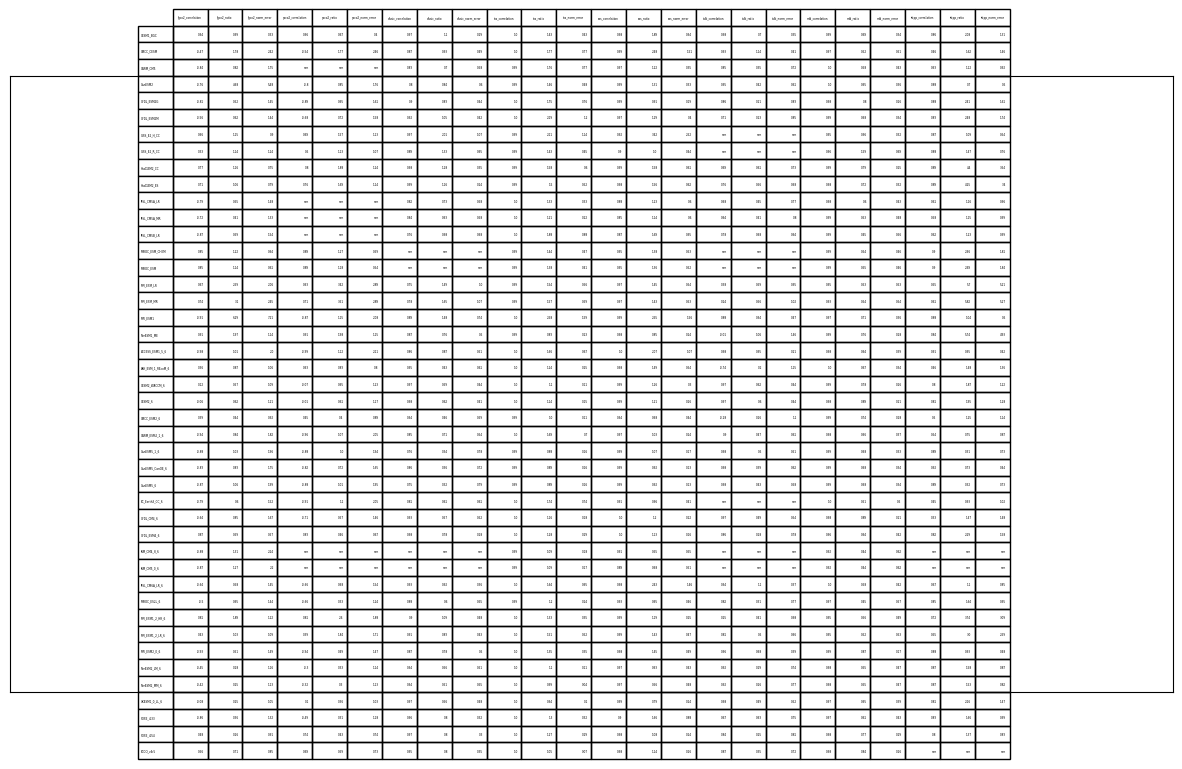

In [ ]:
# vals = np.around(df.values,2)
# norm = plt.Normalize(vals.min()-1, vals.max()+1)
# colours = plt.cm.hot(norm(vals))

# fig = plt.figure(figsize=(15,8))
# ax = fig.add_subplot(111, frameon=True, xticks=[], yticks=[])

# the_table=plt.table(cellText=vals, rowLabels=df.index, colLabels=df.columns, 
#                     colWidths = [0.03]*vals.shape[1], loc='center', 
#                     cellColours=colours)
# plt.show()


In [13]:
df2

,orig_pco2_corr,dic_phase_adj_pco2_corr,dic_amp_adj_pco2_corr,dic_phase_amp_adj_pco2_corr,sst_amp_adj_pco2_corr,talk_phase_adj_pco2_corr,talk_amp_adj_pco2_corr,talk_phase_amp_adj_pco2_corr,dic_phase_amp_sst_phase_amp_adj_pco2_corr,dic_sst_ta_adj_pco2_corr,T_B_ratio
model_name,,,,,,,,,,,
CESM1_BGC,0.965699,0.974813,0.979593,0.943503,0.902399,0.951872,0.966156,0.976283,0.962127,0.976426,0.817705
CMCC_CESM,-0.669754,-0.330985,-0.614044,-0.071320,0.957598,-0.741077,-0.701888,-0.770307,0.969440,0.976429,1.704333
CanESM2,-0.723365,0.647783,-0.216878,0.970766,0.010546,-0.721851,-0.969400,-0.978585,0.910996,0.976651,1.047636
GFDL_ESM2G,-0.954629,-0.040368,-0.252077,0.789841,0.536070,-0.967218,-0.627944,-0.819089,0.920058,0.977784,1.295317
GFDL_ESM2M,-0.957454,0.061454,-0.933719,-0.074273,0.692887,-0.971267,-0.428686,-0.837027,0.926519,0.977936,1.221727
GISS_E2_H_CC,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GISS_E2_R_CC,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HadGEM2_CC,0.916633,0.976505,0.782986,0.903719,0.974136,0.912103,0.855091,0.809690,0.969908,0.977291,0.736937
HadGEM2_ES,0.883382,0.972051,0.814301,0.937984,0.970152,0.876387,0.785939,0.723226,0.965414,0.977263,0.778118


In [16]:
# for each model present in both df and df2, save out both spco2 correlation values, then compare
df_comparison = pd.DataFrame(columns=['model', 'spco2_corr_df1', 'spco2_corr_df2'])
for m in range(0, len(df2.index.values)):
    mod_name = df2.index[m]
    if mod_name in df.index:
        spco2_corr_df1 = df.loc[mod_name,'spco2_correlation']
        spco2_corr_df2 = df2.loc[mod_name,'orig_pco2_corr']
        print(mod_name + ': ' + str(spco2_corr_df1) + ', ' + str(spco2_corr_df2))
        # save values along with model name into a new dataframe
        new_row = pd.DataFrame({'model': [mod_name], 'spco2_corr_df1': [spco2_corr_df1], 'spco2_corr_df2': [spco2_corr_df2]})
        df_comparison = pd.concat([df_comparison, new_row], ignore_index=True)

CESM1_BGC: 0.959114702260481, 0.965699258802647
CMCC_CESM: -0.541379299850222, -0.669754497823048
CanESM2: -0.80170245911252, -0.723364807061774
GFDL_ESM2G: -0.886443779862969, -0.954628980073582
GFDL_ESM2M: -0.677562026132837, -0.957454334313509
GISS_E2_H_CC: 0.693783613537664, nan
GISS_E2_R_CC: 0.499565669515578, nan
HadGEM2_CC: 0.801620647669471, 0.916633195420447
HadGEM2_ES: 0.75668869593997, 0.883382125504916
MIROC_ESM_CHEM: 0.894445915469658, nan
MIROC_ESM: 0.890162023906532, nan
MPI_ESM_LR: 0.631262149221505, 0.666192993813991
MPI_ESM_MR: 0.707547570696985, 0.725145258892347
MRI_ESM1: -0.869558765539195, -0.832298771589682
NorESM1_ME: 0.907827065887582, 0.936137516275401
ACCESS_ESM1_5_6: -0.987862698418821, -0.978960107407786
AWI_ESM_1_REcoM_6: 0.632877428251132, -0.0348470708344485
CESM2_WACCM_6: -0.0674497861525138, -0.0769962031259412
CESM2_6: -0.0111180921625103, -0.0177408672822936
CMCC_ESM2_6: 0.451409554167778, 0.479798618643304
CNRM_ESM2_1_6: -0.96485688420918, -0.953237

/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_59472/3402997972.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparison = pd.concat([df_comparison, new_row], ignore_index=True)


In [17]:
df_comparison

,model,spco2_corr_df1,spco2_corr_df2
0,CESM1_BGC,0.959115,0.965699
1,CMCC_CESM,-0.541379,-0.669754
2,CanESM2,-0.801702,-0.723365
3,GFDL_ESM2G,-0.886444,-0.954629
4,GFDL_ESM2M,-0.677562,-0.957454
5,GISS_E2_H_CC,0.693784,NaN
6,GISS_E2_R_CC,0.499566,NaN
7,HadGEM2_CC,0.801621,0.916633
8,HadGEM2_ES,0.756689,0.883382
9,MIROC_ESM_CHEM,0.894446,NaN


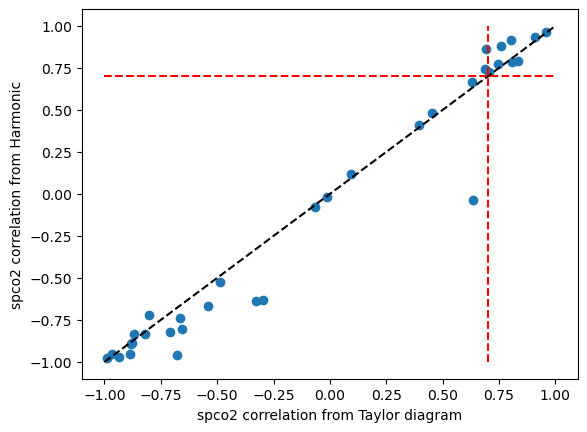

In [23]:
plt.scatter(df_comparison['spco2_corr_df1'], df_comparison['spco2_corr_df2'])
plt.xlabel('spco2 correlation from Taylor diagram')
plt.ylabel('spco2 correlation from Harmonic')
plt.plot([-1,1],[-1,1], 'k--')
plt.plot([.7, .7], [-1,1], 'r--')
plt.plot([-1,1], [.7, .7], 'r--')

In [41]:
df_comparison['model'][np.abs(df_comparison['spco2_corr_df1'] - df_comparison['spco2_corr_df2'])>0.4]

16    AWI_ESM_1_REcoM_6
Name: model, dtype: object

In [29]:
print(df_comparison['model'][df_comparison['spco2_corr_df1']>=0.65])
print(df_comparison['model'][df_comparison['spco2_corr_df2']>=0.65])


0            CESM1_BGC
5         GISS_E2_H_CC
7           HadGEM2_CC
8           HadGEM2_ES
9       MIROC_ESM_CHEM
10           MIROC_ESM
12          MPI_ESM_MR
14          NorESM1_ME
26         GFDL_ESM4_6
27       GISS_E2_1_G_6
30     MPI_ESM1_2_HR_6
37          BSOSE_i154
38    ECCO_v4r5_Darwin
Name: model, dtype: object
0            CESM1_BGC
7           HadGEM2_CC
8           HadGEM2_ES
11          MPI_ESM_LR
12          MPI_ESM_MR
14          NorESM1_ME
26         GFDL_ESM4_6
27       GISS_E2_1_G_6
30     MPI_ESM1_2_HR_6
37          BSOSE_i154
38    ECCO_v4r5_Darwin
Name: model, dtype: object
